# Proyecto 2 — Modelo de Clasificación
## Predicción del Puntaje Global Saber 11 — Departamento del Huila

**Pregunta de negocio:** 

> ¿Es posible predecir si un estudiante asiste a una jornada no convencional (noctura o sabatina) a partir de su perfil socieconómico y municipio?


**Responsable** Juan Sebastián Méndez Martínez

**Rol** Ciencia de Datos / Tablero de datos

**Tipo de modelo** Modelo de clasificación binaria

**Variable objetivo** 0 = Completa,Mañana,Tarde->Jornadas Regulares; 1 = Nocturan, Sabatina -> Jornada No convencional  

**Cliente** Secretaría de Educación del Huila

---
## 1. Librerías - Carga de datos

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
import tensorflow as tf

import mlflow
import mlflow.keras
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

In [19]:
# Carga del conjunto de datos - Proyecto 1
# El archivo corresponde al subconjunto filtrado para el departamento del Huila
# con 19 variables seleccionadas y un tamaño de aproximadamente 29.7 MB
df = pd.read_csv('../tarea2_datos/Datos_Huila_Limpio.csv')
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nDistribución de jornadas:\n{df['jornada'].value_counts()}")
print(f"\nPorcentajes:\n{df['jornada'].value_counts(normalize=True).round(3)*100}%")

Dimensiones del dataset: (111556, 19)

Distribución de jornadas:
jornada
COMPLETA    41293
MAÑANA      26852
SABATINA    17653
TARDE       11666
UNICA        9520
NOCHE        4572
Name: count, dtype: int64

Porcentajes:
jornada
COMPLETA    37.0
MAÑANA      24.1
SABATINA    15.8
TARDE       10.5
UNICA        8.5
NOCHE        4.1
Name: proportion, dtype: float64%


---
## 2. Selección y Preprocesamiento de Variables

### 2.1. Selección de variables

Se seleccionan las variables predictoras con base en su relevancia para responder la pregunta de negocio. La selección se fundamenta en los hallazgos del Proyecto 1.

In [20]:
# Variable objetivo binaria
# Clase 1: jornadas no convencionales (estudiantes que trabajan, adultos)
# Clase 0: jornadas regulares
df['jornada_no_convencional'] = df['jornada'].isin(['SABATINA', 'NOCHE']).astype(int)

print("Distribución del target binario:")
print(df['jornada_no_convencional'].value_counts())
print(f"\nClase minoritaria (No Convencional): "
      f"{df['jornada_no_convencional'].mean() * 100:.2f}%")
df.head()

Distribución del target binario:
jornada_no_convencional
0    89331
1    22225
Name: count, dtype: int64

Clase minoritaria (No Convencional): 19.92%


,periodo,municipio,naturaleza_colegio,area_colegio,jornada,calendario,enfoque_colegio,genero,estrato,educacion_madre,educacion_padre,tiene_internet,tiene_computador,puntaje_matematicas,puntaje_lectura,puntaje_sociales,puntaje_ciencias,puntaje_ingles,puntaje_global,jornada_no_convencional
0,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0,0
1,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0,0
2,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0,0
3,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0,0
4,20152,ALGECIRAS,OFICIAL,URBANO,SABATINA,A,ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,44.0,46.0,49.0,43.0,52.0,230.0,1


In [21]:
# Variables predictoras
# Se excluyen los puntajes por ser consecuencia del rendimiento, no del perfil
# Se excluye 'jornada' porque ES la variable objetivo
# Se excluye 'calendario' y 'enfoque_colegio' por no ser parte
# de la pregunta de negocio (perfil socioeconómico y municipio)
features = [
    'estrato',             # Nivel socioeconómico del hogar (ordinal, 0-6)
    'area_colegio',        # Zona geográfica (urbano/rural)
    'educacion_madre',     # Nivel educativo de la madre (ordinal)
    'educacion_padre',     # Nivel educativo del padre (ordinal)
    'municipio',           # Municipio del establecimiento (nominal, 37 categorías)
    'tiene_internet',      # Acceso a internet en el hogar (binaria)
    'tiene_computador',    # Acceso a computador en el hogar (binaria)
    'naturaleza_colegio',  # Oficial vs No Oficial (binaria)
    'genero'               # Género del estudiante (binaria)
]

target = 'jornada_no_convencional'

# Eliminamos nulos en las variables de interés
df_model = df[features + [target]].dropna()

print(f"Registros disponibles tras eliminar nulos: {len(df_model):,}")
print(f"\nDistribución del target en df_model:")
print(df_model[target].value_counts())

Registros disponibles tras eliminar nulos: 105,542

Distribución del target en df_model:
jornada_no_convencional
0    85423
1    20119
Name: count, dtype: int64


### 2.2 Codificación de Variables Categóricas

La estrategia de codificación se define según la naturaleza de cada variable:

| Variable | Tipo | Estrategia | Justificación |
|---|---|---|---|
| `estrato` | Ordinal | Mapeo numérico 0–6 | Preserva el orden jerárquico |
| `educacion_madre/padre` | Ordinal | Mapeo numérico 0–9 | Preserva la jerarquía educativa |
| `area_colegio`, `tiene_internet`, `tiene_computador`, `genero`, `naturaleza_colegio` | Binaria | Codificación 0/1 | Variables dicotómicas naturales |
| `municipio` | Nominal (37 categorías) | Target encoding | Evita alta dimensionalidad; captura el efecto promedio por municipio |
| `jornada` | Nominal | One-hot encoding | Número reducido de categorías, sin orden inherente |

In [22]:
df_enc = df_model.copy()

# ── 1. Estrato: mapeo ordinal ──────────────────────────────────────────────
estrato_map = {
    'Sin Estrato': 0,
    'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
    'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6
}
df_enc['estrato'] = df_enc['estrato'].map(estrato_map)

# ── 2. Educación de padres: mapeo ordinal ──────────────────────────────────
edu_map = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria incompleta': 3,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria completa': 4,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 6,
    'Educación profesional incompleta': 7,
    'Educación profesional completa': 8,
    'Postgrado': 9
}
df_enc['educacion_madre'] = df_enc['educacion_madre'].map(edu_map)
df_enc['educacion_padre'] = df_enc['educacion_padre'].map(edu_map)

# ── 3. Variables binarias: codificación 0/1 ────────────────────────────────
df_enc['area_colegio']       = (df_enc['area_colegio'] == 'URBANO').astype(int)
df_enc['tiene_internet']     = (df_enc['tiene_internet'] == 'Si').astype(int)
df_enc['tiene_computador']   = (df_enc['tiene_computador'] == 'Si').astype(int)
df_enc['genero']             = (df_enc['genero'] == 'M').astype(int)
df_enc['naturaleza_colegio'] = (df_enc['naturaleza_colegio'] == 'NO OFICIAL').astype(int)

# ── 4. Municipio: target encoding ─────────────────────────────────────────
# DIFERENCIA CLAVE respecto a la pregunta #1:
# En regresión se usó el promedio del puntaje global por municipio.
# En clasificación usaremos la TASA de jornada no convencional por municipio,
# es decir, qué proporción de estudiantes de ese municipio asiste
# a jornada nocturna o sabatina. Esto captura el contexto territorial
# directamente relacionado con la variable objetivo.
mun_target_enc = df_enc.groupby('municipio')[target].mean()
df_enc['municipio'] = df_enc['municipio'].map(mun_target_enc)

# ── Diagnóstico: NaN residuales ────────────────────────────────────────────
nulos = df_enc.isnull().sum()
print("Columnas con NaN residuales tras encoding:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Ninguna — dataset limpio")

df_enc = df_enc.dropna()

print(f"\nRegistros finales para modelado: {len(df_enc):,}")
print(f"Total de variables predictoras: {df_enc.shape[1] - 1}")
print(f"Variables: {df_enc.drop(columns=[target]).columns.tolist()}")

Columnas con NaN residuales tras encoding:
educacion_madre    1560
educacion_padre    4607
dtype: int64

Registros finales para modelado: 100,360
Total de variables predictoras: 9
Variables: ['estrato', 'area_colegio', 'educacion_madre', 'educacion_padre', 'municipio', 'tiene_internet', 'tiene_computador', 'naturaleza_colegio', 'genero']


---
## 3. División y Escalamiento de Datos

Se aplica una partición 80/20 entre entrenamiento y prueba. 

El escalamiento se realiza tanto sobre las variables predictoras como sobre la variable objetivo, con el propósito de estabilizar el entrenamiento de la red neuronal y evitar que la escala del target (rango 100–500) genere gradientes desproporcionados durante la optimización.

In [23]:
X = df_enc.drop(columns=[target]).values
y = df_enc[target].values

# División estratificada 80% / 20%
# stratify=y es OBLIGATORIO en clasificación desbalanceada:
# garantiza que ambas particiones mantengan la misma proporción
# de clase minoritaria (~19.9%) que el dataset completo.
# Sin esto, por azar podría quedar muy poca clase 1 en el test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]:,} registros, "
      f"{X_train.shape[1]} features")
print(f"Conjunto de prueba:        {X_test.shape[0]:,} registros")

Conjunto de entrenamiento: 80,288 registros, 9 features
Conjunto de prueba:        20,072 registros


In [24]:
# Escalamiento de variables predictoras
# fit_transform sobre train, solo transform sobre test (evita data leakage)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# NO se escala la variable objetivo porque ya es binaria (0/1).
# En regresión era necesario escalar el target (rango 100-500)
# para estabilizar los gradientes. Aquí no aplica.
print("Verificación de proporciones tras la división (stratify=y):")
print(f"  Clase 1 en train: {y_train.mean() * 100:.2f}%")
print(f"  Clase 1 en test:  {y_test.mean() * 100:.2f}%")
print(f"  Clase 1 total:    {y.mean() * 100:.2f}%")

Verificación de proporciones tras la división (stratify=y):
  Clase 1 en train: 18.99%
  Clase 1 en test:  18.99%
  Clase 1 total:    18.99%


In [25]:
# Cálculo de pesos de clase para compensar el desbalance
# Con ~19.9% de clase minoritaria, el modelo sin compensación
# tenderá a predecir siempre clase 0 y obtener ~80% de accuracy,
# lo cual es inútil para la Secretaría de Educación.
#
# class_weight='balanced' calcula automáticamente:
#   peso_clase_i = n_total / (n_clases * n_muestras_clase_i)
# Esto hace que cada error en la clase minoritaria "pese" más
# durante el entrenamiento, forzando al modelo a aprender ambas clases.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Pesos de clase calculados:")
print(f"  Clase 0 (Convencional):     {class_weight_dict[0]:.4f}")
print(f"  Clase 1 (No Convencional):  {class_weight_dict[1]:.4f}")
print(f"\n→ Cada error en clase 1 penaliza ~"
      f"{class_weight_dict[1]/class_weight_dict[0]:.1f}x "
      f"más que un error en clase 0.")

Pesos de clase calculados:
  Clase 0 (Convencional):     0.6172
  Clase 1 (No Convencional):  2.6329

→ Cada error en clase 1 penaliza ~4.3x más que un error en clase 0.


---
## 4. Modelo Base de Regresión

### 4.1 Modelo Base

Se define una red neuronal de referencia con arquitectura simple: 

Dos capas ocultas con activación ReLU y una capa de salida que usa SIGMOID para producir una probabilidad entre 0 y 1. La función de pérdida empleada es el entropía cruzada binaria. 

Se utiliza un *callback* de Early Stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar, evitando el sobreajuste.

In [26]:
n_features = X_train.shape[1]

def build_model_base_clf():
    """
    Modelo base de clasificación binaria.
    Arquitectura: Input → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)
    
    La capa de salida usa SIGMOID (no lineal como en regresión)
    porque produce una probabilidad entre 0 y 1.
    La pérdida es binary_crossentropy, estándar para clasificación binaria.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # ← DIFERENCIA CLAVE vs regresión
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',     # ← DIFERENCIA CLAVE vs regresión (MSE)
        metrics=['accuracy', AUC(name='auc')]
    )
    return model

model_base_clf = build_model_base_clf()
model_base_clf.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7156 - auc: 0.7923 - loss: 0.5452 - val_accuracy: 0.7464 - val_auc: 0.8221 - val_loss: 0.5058
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7532 - auc: 0.8215 - loss: 0.5109 - val_accuracy: 0.7528 - val_auc: 0.8267 - val_loss: 0.5021
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7548 - auc: 0.8246 - loss: 0.5070 - val_accuracy: 0.7534 - val_auc: 0.8281 - val_loss: 0.4996
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7558 - auc: 0.8262 - loss: 0.5049 - val_accuracy: 0.7524 - val_auc: 0.8291 - val_loss: 0.4996
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7561 - auc: 0.8272 - loss: 0.5035 - val_accuracy: 0.7527 - val_auc: 0.8296 - val_loss: 0.4992
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7574 - auc: 0.8280 - loss: 0.5025 - val_accuracy: 0.7548 - val_auc: 0.8300 - val_loss: 0.4986
Epoch 7/100
314/314 ━━━━━━━━━━━━━━

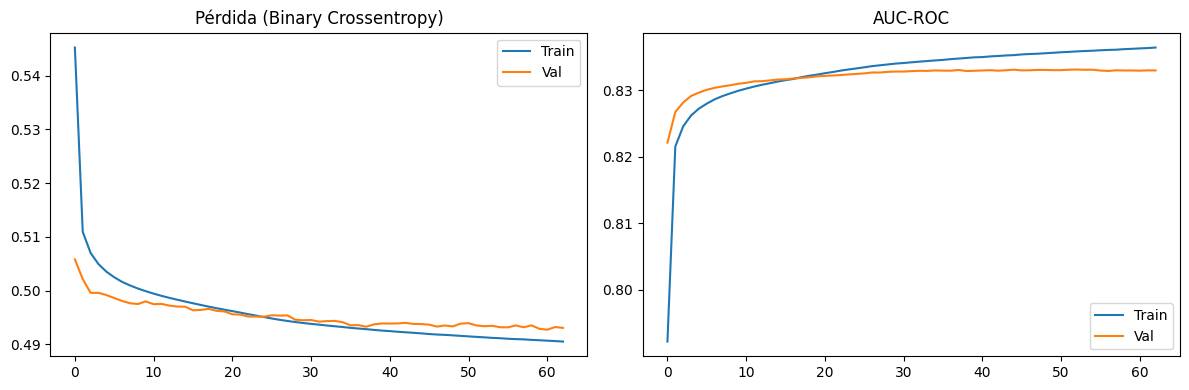

In [27]:
early_stop = EarlyStopping(
    monitor='val_auc',        # Monitorear AUC para clasificación desbalanceada
    patience=10,
    restore_best_weights=True,
    mode='max',               # Maximizar AUC (diferente a minimizar pérdida)
    verbose=1
)

history_base = model_base_clf.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,  # ← Manejo del desbalance
    callbacks=[early_stop],
    verbose=1
)

# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_base.history['loss'], label='Train')
ax1.plot(history_base.history['val_loss'], label='Val')
ax1.set_title('Pérdida (Binary Crossentropy)')
ax1.legend()

ax2.plot(history_base.history['auc'], label='Train')
ax2.plot(history_base.history['val_auc'], label='Val')
ax2.set_title('AUC-ROC')
ax2.legend()
plt.tight_layout()
plt.show()

### 4.2 Métricas de Evaluación del Modelo Base

Se calculan métricas como AUC-ROC, Precision, Recall, y F1-Score


--- MÉTRICAS Base ---
AUC-ROC: 0.8331

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.92      0.75      0.83     16260
No Convencional       0.41      0.74      0.53      3812

       accuracy                           0.75     20072
      macro avg       0.67      0.75      0.68     20072
   weighted avg       0.83      0.75      0.77     20072



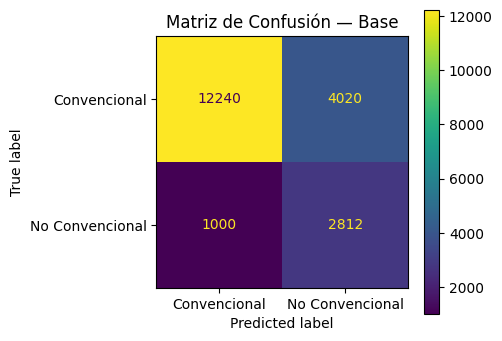

In [28]:
def evaluar_modelo_clf(model, X_test, y_test, nombre='Modelo', umbral=0.5):
    """
    Para clasificación binaria las métricas cambian completamente respecto
    a regresión. Las más relevantes son:
    
    - AUC-ROC: capacidad discriminativa global (0.5 = aleatorio, 1.0 = perfecto)
    - Precision: de los predichos como positivo, cuántos son realmente positivos
    - Recall: de los positivos reales, cuántos detectamos
    - F1-Score: media armónica de Precision y Recall
    
    Para clases desbalanceadas, el accuracy es engañoso.
    """
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= umbral).astype(int)
    
    auc   = roc_auc_score(y_test, y_prob)
    
    print(f"\n--- MÉTRICAS {nombre} ---")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"\nReporte de clasificación (umbral={umbral}):")
    print(classification_report(y_test, y_pred,
                                 target_names=['Convencional', 'No Convencional']))
    
    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Convencional', 'No Convencional'],
        ax=ax
    )
    ax.set_title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()
    
    return {'Modelo': nombre, 'AUC': round(auc, 4)}

metricas_base = evaluar_modelo_clf(model_base_clf, X_test, y_test, 'Base')
results_all = [metricas_base]

**Análisis del modelo base:**

El valor **AUC-ROC=0.8337** nos da indicios de que el modelo tiene una buena capacidad para detectar las dos clases. Sin embargo, el desempeño es mejor para la clase convencional (completa,mañana,tarde,completa,unica) que para la clase No convencional (sabatina, noche). Si bien el modelo logra identificar el 73% de los casos No convencionales, su precisión es de 42%, indicando una cantidad considerable de falsos positivos.

---
## 5. Experimentación con Variaciones de la Arquitectura

### 5.1 Modelos

Con el fin de identificar la configuración óptima, se evalúan tres arquitecturas adicionales que modifican la profundidad de la red, la regularización y la tasa de aprendizaje. Todas las variaciones emplean los mismos datos de entrenamiento y prueba para garantizar comparabilidad.

In [35]:
def build_model_1_clf():
    """
    Modelo 1 — Red Profunda.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


def build_model_2_clf():
    """
    Modelo 2 — Red con Dropout.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


def build_model_3_clf():
    """
    Modelo 3 — Arquitectura simple con LR conservador.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


--- MÉTRICAS Modelo 1 - Red Profunda ---
AUC-ROC: 0.8336

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.93      0.73      0.82     16260
No Convencional       0.40      0.76      0.52      3812

       accuracy                           0.73     20072
      macro avg       0.66      0.74      0.67     20072
   weighted avg       0.83      0.73      0.76     20072



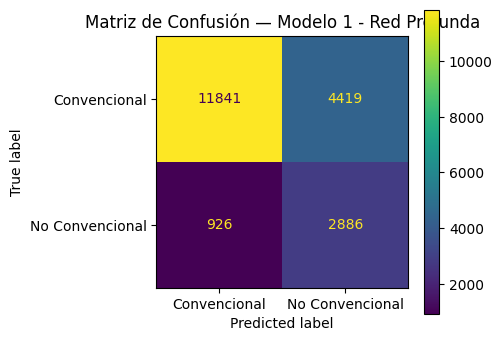


--- MÉTRICAS Modelo 2 - Con Dropout ---
AUC-ROC: 0.8369

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.92      0.79      0.85     16260
No Convencional       0.44      0.71      0.54      3812

       accuracy                           0.77     20072
      macro avg       0.68      0.75      0.70     20072
   weighted avg       0.83      0.77      0.79     20072



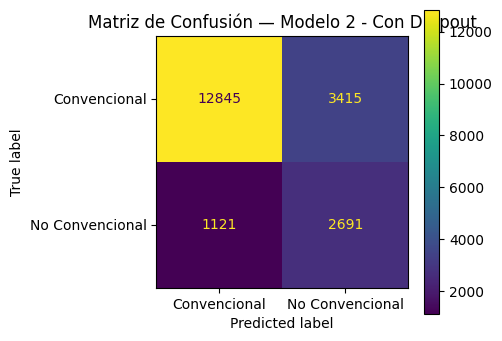


--- MÉTRICAS Modelo 3 - Simple + LR bajo ---
AUC-ROC: 0.8322

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.92      0.76      0.83     16260
No Convencional       0.42      0.73      0.53      3812

       accuracy                           0.75     20072
      macro avg       0.67      0.75      0.68     20072
   weighted avg       0.83      0.75      0.78     20072



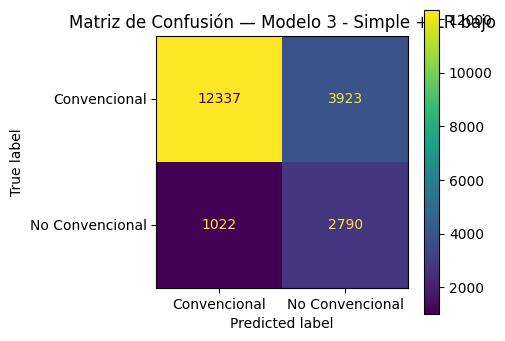

In [36]:
configs_clf = [
    (build_model_1_clf, 'Modelo 1 - Red Profunda'),
    (build_model_2_clf, 'Modelo 2 - Con Dropout'),
    (build_model_3_clf, 'Modelo 3 - Simple + LR bajo'),
]

histories_clf = {}

for build_fn, nombre in configs_clf:
    m = build_fn()
    h = m.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode='max'
        )],
        verbose=0
    )
    histories_clf[nombre] = h
    metricas = evaluar_modelo_clf(m, X_test, y_test, nombre)
    results_all.append(metricas)

In [37]:
# Tabla comparativa de AUC por modelo
df_results_clf = pd.DataFrame(results_all)
print(df_results_clf.to_string(index=False))

                     Modelo    AUC
                       Base 0.8331
    Modelo 1 - Red Profunda 0.8340
     Modelo 2 - Con Dropout 0.8341
Modelo 3 - Simple + LR bajo 0.8324
    Modelo 1 - Red Profunda 0.8336
     Modelo 2 - Con Dropout 0.8369
Modelo 3 - Simple + LR bajo 0.8322


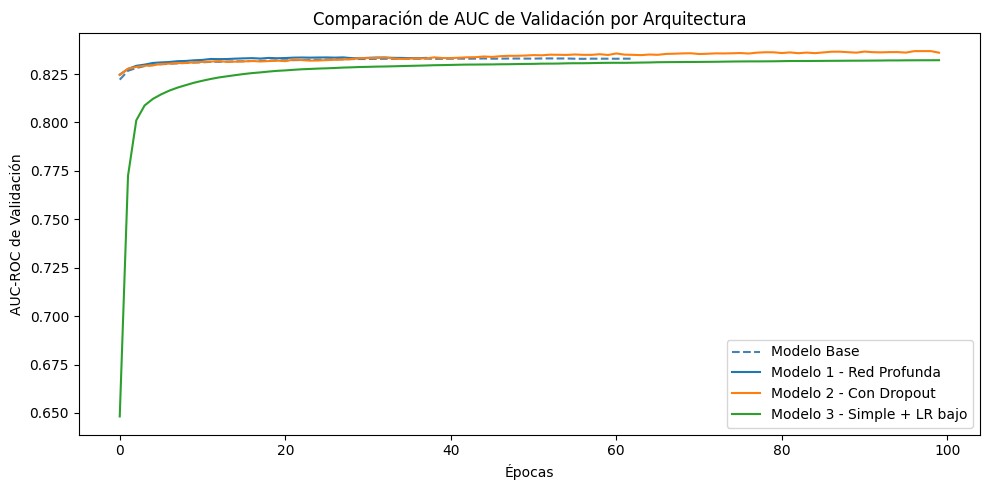

In [38]:
# Comparación visual de curvas AUC de validación
plt.figure(figsize=(10, 5))

plt.plot(
    history_base.history['val_auc'],
    label='Modelo Base',
    linestyle='--',
    color='steelblue'
)

for nombre, h in histories_clf.items():
    plt.plot(h.history['val_auc'], label=nombre)

plt.title('Comparación de AUC de Validación por Arquitectura')
plt.xlabel('Épocas')
plt.ylabel('AUC-ROC de Validación')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2. Análisis comparativo de arquitecturas:

Los cuatro modelos evaluados presentan métricas muy similares. El **Modelo 2** obtuvo el mejor desempeño global (AUC: 0.8369), seguido muy de cerca por el Modelo 1 y el Modelo Base.

Podemos concluir que la utilizacion de el Dropout logro aportar mejoras a nuestro modelo. Como las clases desbalanceadas pueden causar que la red memorice patrones mayoritarios de la clase 0, al usar esta tecnica se activa un tipo de "regularizador" que evita dicho comportamiento y fuerza representaciones mas robustas para amabas clases.

Seleccionamos el **Modelo 2** como modelo final.


### DESDE AQUI ES EL CODIGO PARA REGRESION

---
## 6. Registro de Experimentos con MLflow

Se registran los cuatro experimentos en MLflow para documentar los parámetros, métricas y artefactos de cada configuración. Esto permite trazabilidad completa del proceso de modelado y facilita la reproducción de resultados.

In [ ]:
# Configuración del servidor de tracking local
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Regresion_PuntajeGlobal_Huila")

configs_mlflow = [
    {'nombre': 'Modelo_Base',      'build_fn': build_model_base, 'lr': 0.0001, 'dropout': False, 'capas': 2},
    {'nombre': 'Modelo_Profundo',  'build_fn': build_model_1,    'lr': 0.0001, 'dropout': False, 'capas': 4},
    {'nombre': 'Modelo_Dropout',   'build_fn': build_model_2,    'lr': 0.0001, 'dropout': True,  'capas': 3},
    {'nombre': 'Modelo_Simple_LR', 'build_fn': build_model_3,    'lr': 0.001,  'dropout': False, 'capas': 2},
]

for cfg in configs_mlflow:
    with mlflow.start_run(run_name=cfg['nombre']):

        # Registro de hiperparámetros
        mlflow.log_param('learning_rate',    cfg['lr'])
        mlflow.log_param('dropout',          cfg['dropout'])
        mlflow.log_param('capas_ocultas',    cfg['capas'])
        mlflow.log_param('batch_size',       256)
        mlflow.log_param('epochs_max',       100)
        mlflow.log_param('early_stopping',   True)
        mlflow.log_param('optimizer',        'Adam')
        mlflow.log_param('target_escalado',  True)

        # Entrenamiento con los mismos parámetros de la sección 4 y 5
        m = cfg['build_fn']()
        m.fit(
            X_train, y_train_scaled,
            validation_data=(X_test, y_test_scaled),
            epochs=100,
            batch_size=256,
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
            verbose=0
        )

        # Cálculo de métricas en escala original
        y_pred_sc = m.predict(X_test, verbose=0).flatten()
        y_pred    = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        # Registro de métricas y artefacto del modelo
        mlflow.log_metric('RMSE', rmse)
        mlflow.log_metric('MAE',  mae)
        mlflow.log_metric('R2',   r2)
        mlflow.keras.log_model(m, artifact_path='model')

        print(f"{cfg['nombre']:<22} — RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

print("\nExperimentos registrados exitosamente en MLflow.")

---
## 7. Serialización del Modelo Final

Con base en los resultados de la sección 5, se selecciona el **Modelo Base** como modelo final por presentar el menor RMSE (40.44) y el mayor R² (0.2748), junto con la mayor estabilidad durante el entrenamiento. 

El modelo se serializa junto con los transformadores necesarios para garantizar que el tablero Dash pueda realizar predicciones coherentes sobre nuevas entradas del usuario.

In [ ]:
# Reentrenamiento del modelo final seleccionado
mejor_modelo = build_model_base()

mejor_modelo.fit(
    X_train, y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=100,
    batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Creación del directorio de modelos para el tablero
os.makedirs('../tarea5_tablero/modelos', exist_ok=True)

# Serialización en formato .keras (compatible con Keras 3)
# Se guarda el modelo y ambos transformadores para reproducir el pipeline completo
mejor_modelo.save('../tarea5_tablero/modelos/modelo_regresion.keras')
joblib.dump(scaler_X,          '../tarea5_tablero/modelos/scaler_X_regresion.pkl')
joblib.dump(scaler_y,          '../tarea5_tablero/modelos/scaler_y_regresion.pkl')
joblib.dump(mun_target_enc.to_dict(), '../tarea5_tablero/modelos/municipio_encoder.pkl')

print("Archivos guardados:")
print("  - modelo_regresion.keras       (red neuronal entrenada)")
print("  - scaler_X_regresion.pkl       (normalizador de features)")
print("  - scaler_y_regresion.pkl       (normalizador del target)")
print("  - municipio_encoder.pkl        (target encoding de municipio)")

In [ ]:
# Verificación de la serialización
# Se carga el modelo desde disco y se realizan predicciones de prueba
# para confirmar que el pipeline completo funciona correctamente
from tensorflow.keras.models import load_model

modelo_cargado   = load_model('../tarea5_tablero/modelos/modelo_regresion.keras')
scaler_y_cargado = joblib.load('../tarea5_tablero/modelos/scaler_y_regresion.pkl')

# Predicción sobre los primeros 5 registros del conjunto de prueba
y_pred_scaled_check = modelo_cargado.predict(X_test[:5], verbose=0).flatten()
y_pred_check = scaler_y_cargado.inverse_transform(y_pred_scaled_check.reshape(-1, 1)).flatten()

print("Verificación de predicciones post-carga:")
print(f"  Predicciones: {y_pred_check.round(1)}")
print(f"  Valores reales: {y_test[:5].round(1)}")
print("\nModelo cargado y verificado correctamente ✓")

In [ ]:
# Guardar el orden de columnas del modelo (necesario para el tablero)
feature_columns = df_enc.drop(columns=[target]).columns.tolist()
joblib.dump(feature_columns, '../tarea5_tablero/modelos/feature_columns_regresion.pkl')
print("Columnas guardadas:", feature_columns)

---
## 8. Conclusiones




**Resultados del modelo seleccionado (Modelo Base)**

| Métrica | Valor | Interpretación |
|---|---|---|
| **RMSE** | 40.44 puntos | Error promedio de predicción en la escala del puntaje global |
| **MAE** | 32.44 puntos | Error absoluto promedio, menos sensible a valores extremos |
| **R²** | 0.2748 | El modelo explica el 27.5% de la variabilidad del puntaje global |

### Hallazgos principales

1. **Capacidad predictiva del perfil socioeconómico:** Un R² de 0.27 indica que las variables socioeconómicas e institucionales capturan aproximadamente la cuarta parte de la variabilidad del puntaje global. Este resultado, aunque moderado, es consistente con la evidencia del Proyecto 1, donde se identificó que la zona geográfica y el estrato son los determinantes estructurales más relevantes del rendimiento en el Huila.

2. **Límite estructural del enfoque:** El error de predicción residual (~72.5% no explicado) refleja factores no capturados por el modelo: calidad docente, motivación del estudiante, metodología pedagógica y condiciones familiares no observadas. Esto no constituye una limitación del modelo neuronal en sí, sino del conjunto de variables disponibles.

3. **Arquitectura óptima:** El Modelo Base (dos capas ocultas, 32 y 16 neuronas) superó o igualó a configuraciones más complejas. La Red Profunda (Modelo 1) presentó inestabilidad por sobrepasar la capacidad necesaria para el problema. El Dropout (Modelo 2) no aportó mejoras al no existir sobreajuste en el modelo base.

4. **Utilidad para la Secretaría de Educación:** El modelo permite estimar el puntaje esperado de un estudiante dado su perfil socioeconómico e institucional, lo cual es útil para identificar estudiantes en riesgo de bajo rendimiento antes de la aplicación del examen y para simular el impacto de intervenciones como la mejora de conectividad o el cambio de jornada escolar.